## Dictionary (Columns):
1. WindSpeed
2. Sunshine
2. AirPressure
4. Radiation
5. AirTemperature
6. RelativeAirHumidity
7. SystemProduction (Target)

In [50]:



import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from scipy.stats import shapiro, normaltest, kurtosis, skew
from statsmodels.stats.diagnostic import lilliefors
from statsmodels.api import qqplot
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, f_regression, RFECV
import joblib
import os

In [51]:
df= pd.read_csv(r"C:\Users\deeks\OneDrive\Desktop\Learn\solar\Solar Power Plant Data.csv")
df.head()

,Date-Hour(NMT),WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
0,01.01.2017-00:00,0.6,0,1003.8,-7.4,0.1,97,0.0
1,01.01.2017-01:00,1.7,0,1003.5,-7.4,-0.2,98,0.0
2,01.01.2017-02:00,0.6,0,1003.4,-6.7,-1.2,99,0.0
3,01.01.2017-03:00,2.4,0,1003.3,-7.2,-1.3,99,0.0
4,01.01.2017-04:00,4.0,0,1003.1,-6.3,3.6,67,0.0


In [52]:
df.shape

(8760, 8)

## Data Wrangling

In [53]:
# check the data frame for missing values and incorrect data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date-Hour(NMT)       8760 non-null   object 
 1   WindSpeed            8760 non-null   float64
 2   Sunshine             8760 non-null   int64  
 3   AirPressure          8760 non-null   float64
 4   Radiation            8760 non-null   float64
 5   AirTemperature       8760 non-null   float64
 6   RelativeAirHumidity  8760 non-null   int64  
 7   SystemProduction     8760 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 547.6+ KB


In [54]:
# Missing data:
df.isna().sum()

Date-Hour(NMT)         0
WindSpeed              0
Sunshine               0
AirPressure            0
Radiation              0
AirTemperature         0
RelativeAirHumidity    0
SystemProduction       0
dtype: int64

There is no missing value in the dataset

In [55]:
# Changing Date-Hour(NMT) column type:
df['Date-Hour(NMT)'] = pd.to_datetime(df['Date-Hour(NMT)'], format="%d.%m.%Y-%H:%M")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date-Hour(NMT)       8760 non-null   datetime64[ns]
 1   WindSpeed            8760 non-null   float64       
 2   Sunshine             8760 non-null   int64         
 3   AirPressure          8760 non-null   float64       
 4   Radiation            8760 non-null   float64       
 5   AirTemperature       8760 non-null   float64       
 6   RelativeAirHumidity  8760 non-null   int64         
 7   SystemProduction     8760 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 547.6 KB


Date column is converted into datetime format.

In [56]:
# Setting the Date-Hour(NUMT) as the index:
df.set_index("Date-Hour(NMT)", inplace=True)

## Exploratory Data Analysis

In [57]:
# get the statistical summary
df.describe()

,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2.639823,11.180479,1010.361781,97.538493,6.978893,76.719406,684.746071
std,1.628754,21.171295,12.793971,182.336029,7.604266,19.278996,1487.454665
min,0.000000,0.000000,965.900000,-9.300000,-12.400000,13.000000,0.000000
25%,1.400000,0.000000,1002.800000,-6.200000,0.500000,64.000000,0.000000
50%,2.300000,0.000000,1011.000000,-1.400000,6.400000,82.000000,0.000000
75%,3.600000,7.000000,1018.200000,115.600000,13.400000,93.000000,464.249950
max,10.900000,60.000000,1047.300000,899.700000,27.100000,100.000000,7701.000000


In [58]:
# Let's see how many data points have negative Radiation:
df[df["Radiation"] < 0].shape

(4464, 7)

More than 50% of the values of Radiation variable are negative where there is no energy generation. But these negative values seem to be due to mishandling of data because Radiation cannot have negative values (the instance where PV panels instead of sun emit radiation). So, these negative values might be mistyped. lets remove the negative values:

In [59]:
df["Radiation"] = df["Radiation"].astype(str).str.replace("-", "", regex=False).astype(float)
df["Radiation"]

Date-Hour(NMT)
2017-01-01 00:00:00    7.4
2017-01-01 01:00:00    7.4
2017-01-01 02:00:00    6.7
2017-01-01 03:00:00    7.2
2017-01-01 04:00:00    6.3
                      ... 
2017-12-31 19:00:00    4.8
2017-12-31 20:00:00    5.0
2017-12-31 21:00:00    5.3
2017-12-31 22:00:00    5.4
2017-12-31 23:00:00    5.9
Name: Radiation, Length: 8760, dtype: float64

In [60]:
df[df["Radiation"] < 0].shape

(0, 7)

Now, there are no negative values.

In [61]:
# Range of datetime column:
print(f"Range of Datetime column: ({df.index.min()}) to ({df.index.max()})")

Range of Datetime column: (2017-01-01 00:00:00) to (2017-12-31 23:00:00)


In [62]:
# Analysing average monthly Radiation and Sunshine:
df["Months"] = df.index.month_name()
df["Month_number"] = df.index.month
monthly_rad_sun = df.groupby(["Month_number", "Months"]).agg({"Radiation":"mean", "Sunshine":"mean"}).droplevel(level="Month_number")

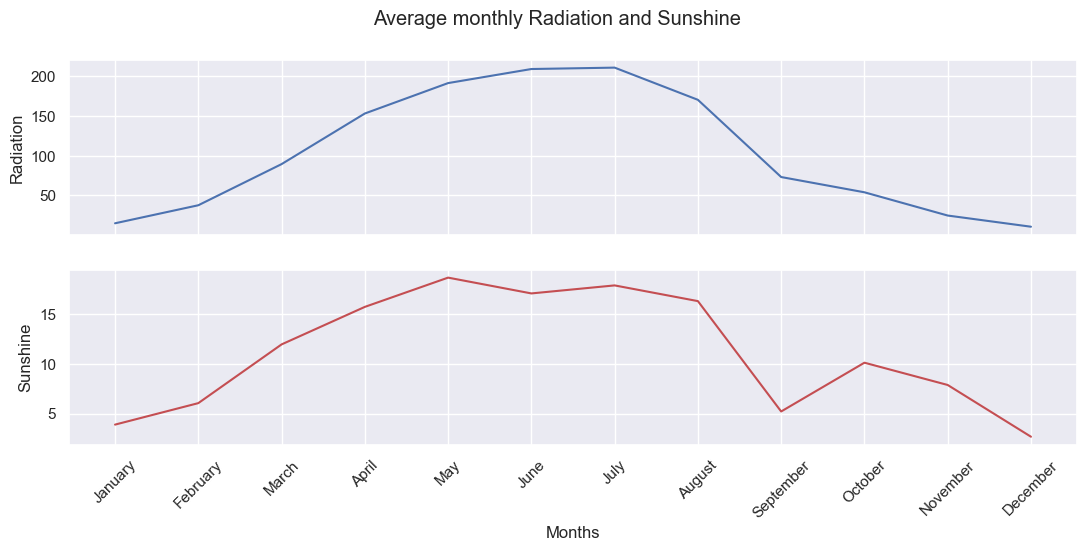

In [63]:
# Line plot of the Average monthly Radiation and Sushine
fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(13, 5))
fig.suptitle("Average monthly Radiation and Sunshine")
plt.xticks(rotation=45)
sns.lineplot(monthly_rad_sun["Radiation"], ax=ax[0])
sns.lineplot(monthly_rad_sun["Sunshine"], ax=ax[1], c="r");

In [64]:
# Dropping Months and Month_number columns:
df.drop(columns=["Months", "Month_number"], inplace=True)

In [65]:
df.head()

,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
Date-Hour(NMT),,,,,,,
2017-01-01 00:00:00,0.6,0,1003.8,7.4,0.1,97,0.0
2017-01-01 01:00:00,1.7,0,1003.5,7.4,-0.2,98,0.0
2017-01-01 02:00:00,0.6,0,1003.4,6.7,-1.2,99,0.0
2017-01-01 03:00:00,2.4,0,1003.3,7.2,-1.3,99,0.0
2017-01-01 04:00:00,4.0,0,1003.1,6.3,3.6,67,0.0


#### We will look at the histogram of all variables

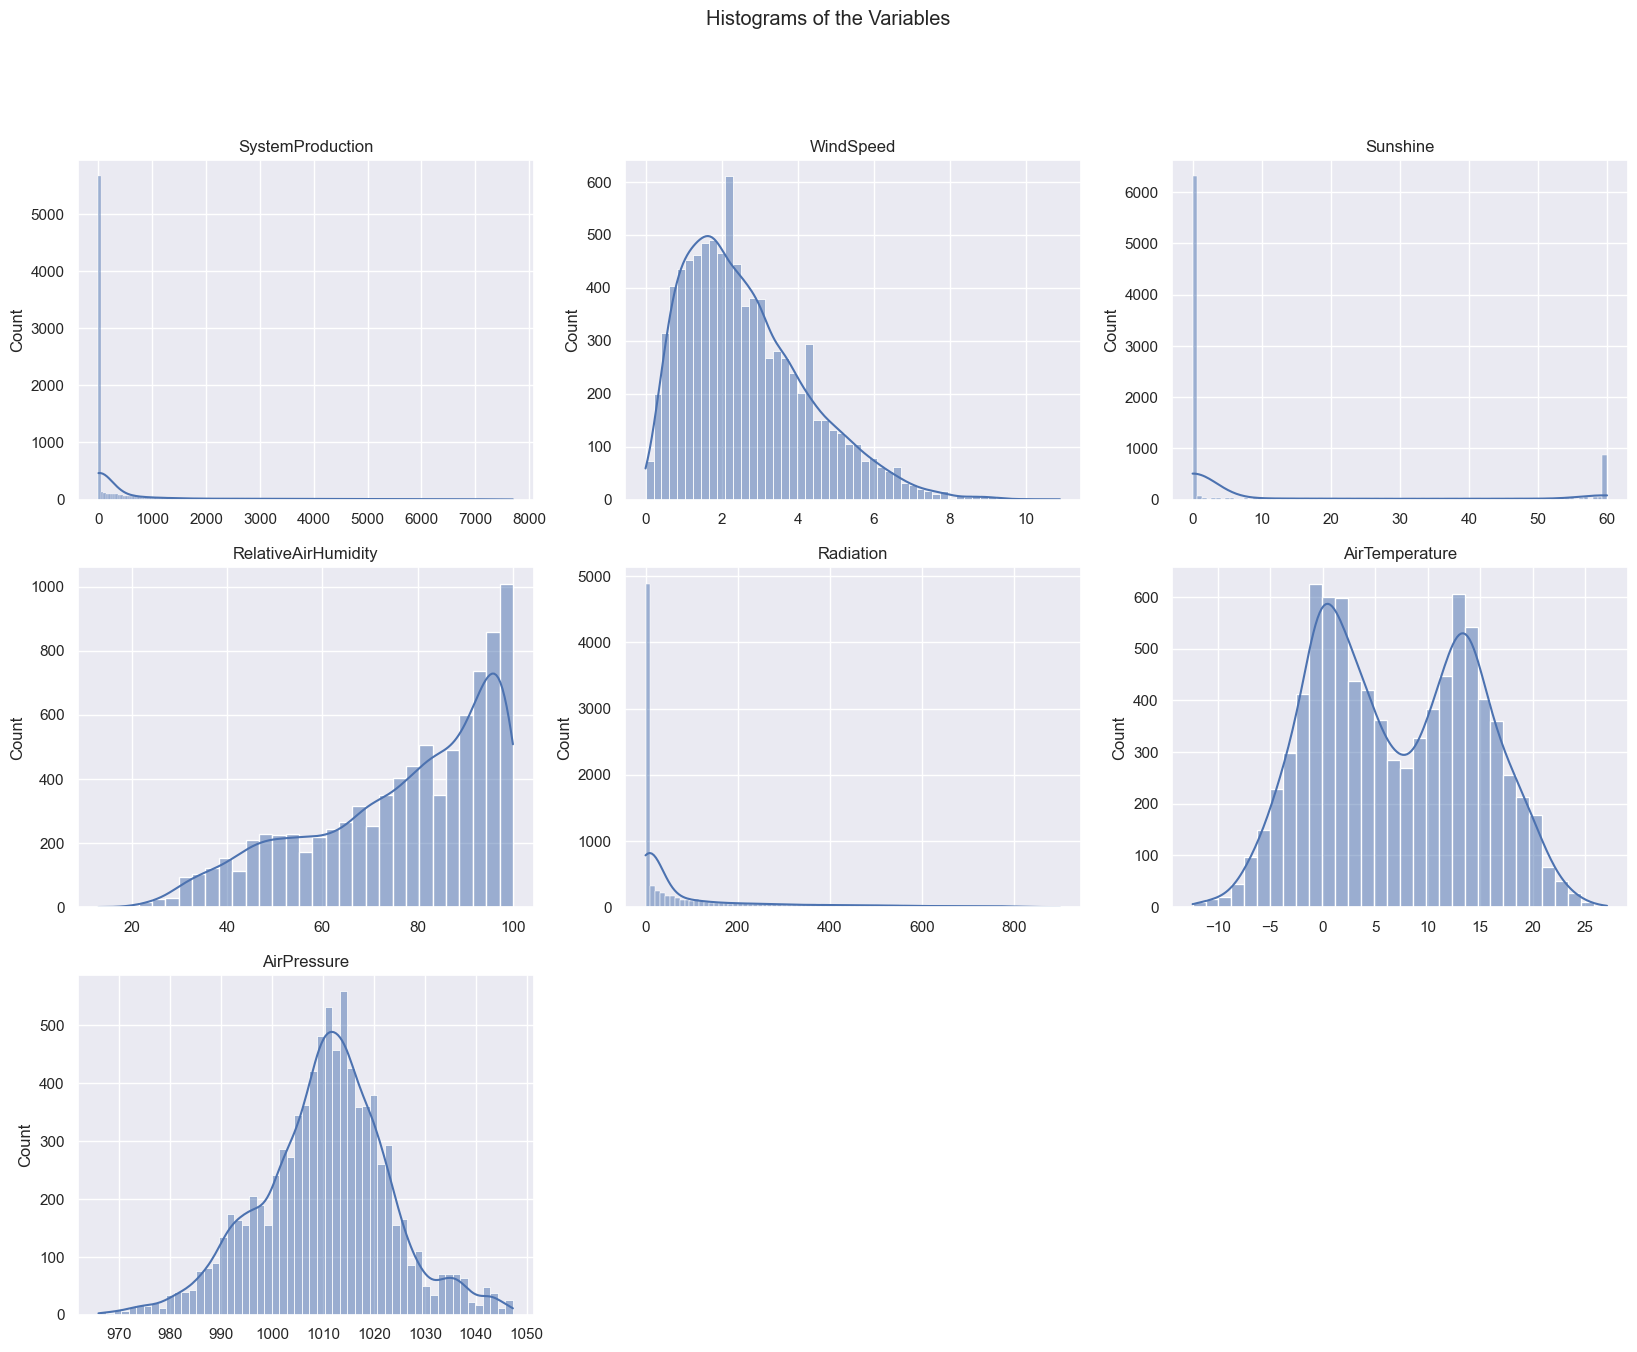

In [66]:
# Histograms:
fig, axes = plt.subplots(nrows=3, ncols=3, sharey=False, figsize=(20, 15))
fig.suptitle("Histograms of the Variables")
sns.histplot(df["SystemProduction"].values, ax=axes[0, 0], kde=True)
axes[0, 0].set_title("SystemProduction")
sns.histplot(df["WindSpeed"].values, ax=axes[0, 1], kde=True)
axes[0, 1].set_title("WindSpeed")
sns.histplot(df["Sunshine"].values, ax=axes[0][2], kde=True)
axes[0][2].set_title("Sunshine")
sns.histplot(df["RelativeAirHumidity"].values, ax=axes[1, 0], kde=True)
axes[1, 0].set_title("RelativeAirHumidity")
sns.histplot(df["Radiation"].values, ax=axes[1, 1], kde=True, legend=False)
axes[1, 1].set_title("Radiation")
sns.histplot(df["AirTemperature"].values, ax=axes[1, 2], kde=True)
axes[1, 2].set_title("AirTemperature")
sns.histplot(df["AirPressure"].values, ax=axes[2, 0], kde=True)
axes[2, 0].set_title("AirPressure");
axes[2, 1].set_visible(False)
axes[2, 2].set_visible(False)

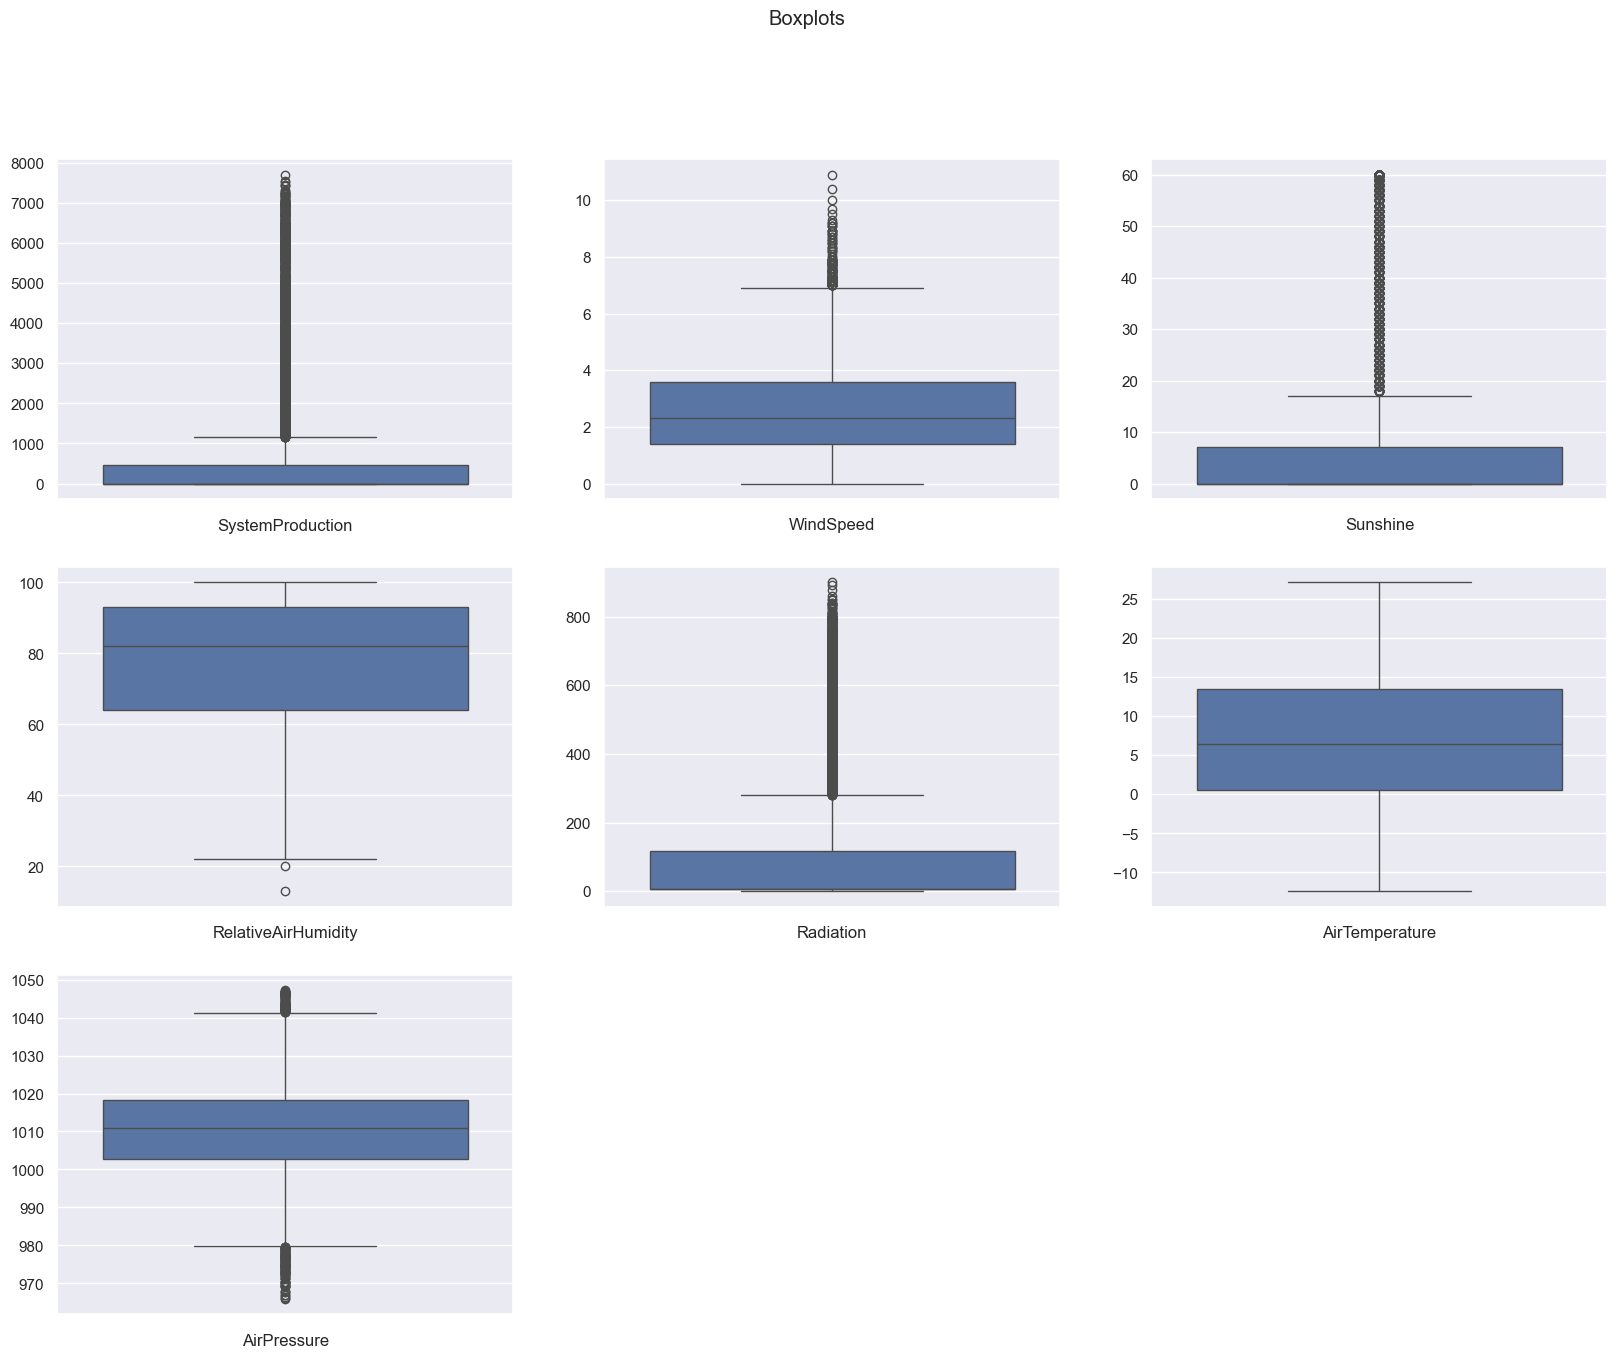

In [67]:
# BoxPlots:
fig, ax = plt.subplots(3, 3, figsize=(20, 15), sharey=False)
fig.suptitle("Boxplots")
sns.boxplot(y=df["SystemProduction"].values, ax=ax[0, 0])
ax[0, 0].set_xlabel("SystemProduction")
sns.boxplot(y=df["WindSpeed"].values, ax=ax[0, 1])
ax[0, 1].set_xlabel("WindSpeed")
sns.boxplot(y=df["Sunshine"].values, ax=ax[0, 2])
ax[0, 2].set_xlabel("Sunshine")
sns.boxplot(y=df["RelativeAirHumidity"].values, ax=ax[1, 0])
ax[1, 0].set_xlabel("RelativeAirHumidity")
sns.boxplot(y=df["Radiation"].values, ax=ax[1, 1])
ax[1, 1].set_xlabel("Radiation")
sns.boxplot(y=df["AirTemperature"].values, ax=ax[1, 2])
ax[1, 2].set_xlabel("AirTemperature")
sns.boxplot(y=df["AirPressure"].values, ax=ax[2, 0])
ax[2, 0].set_xlabel("AirPressure");
ax[2, 1].set_visible(False)
ax[2, 2].set_visible(False)

#### Normality test:

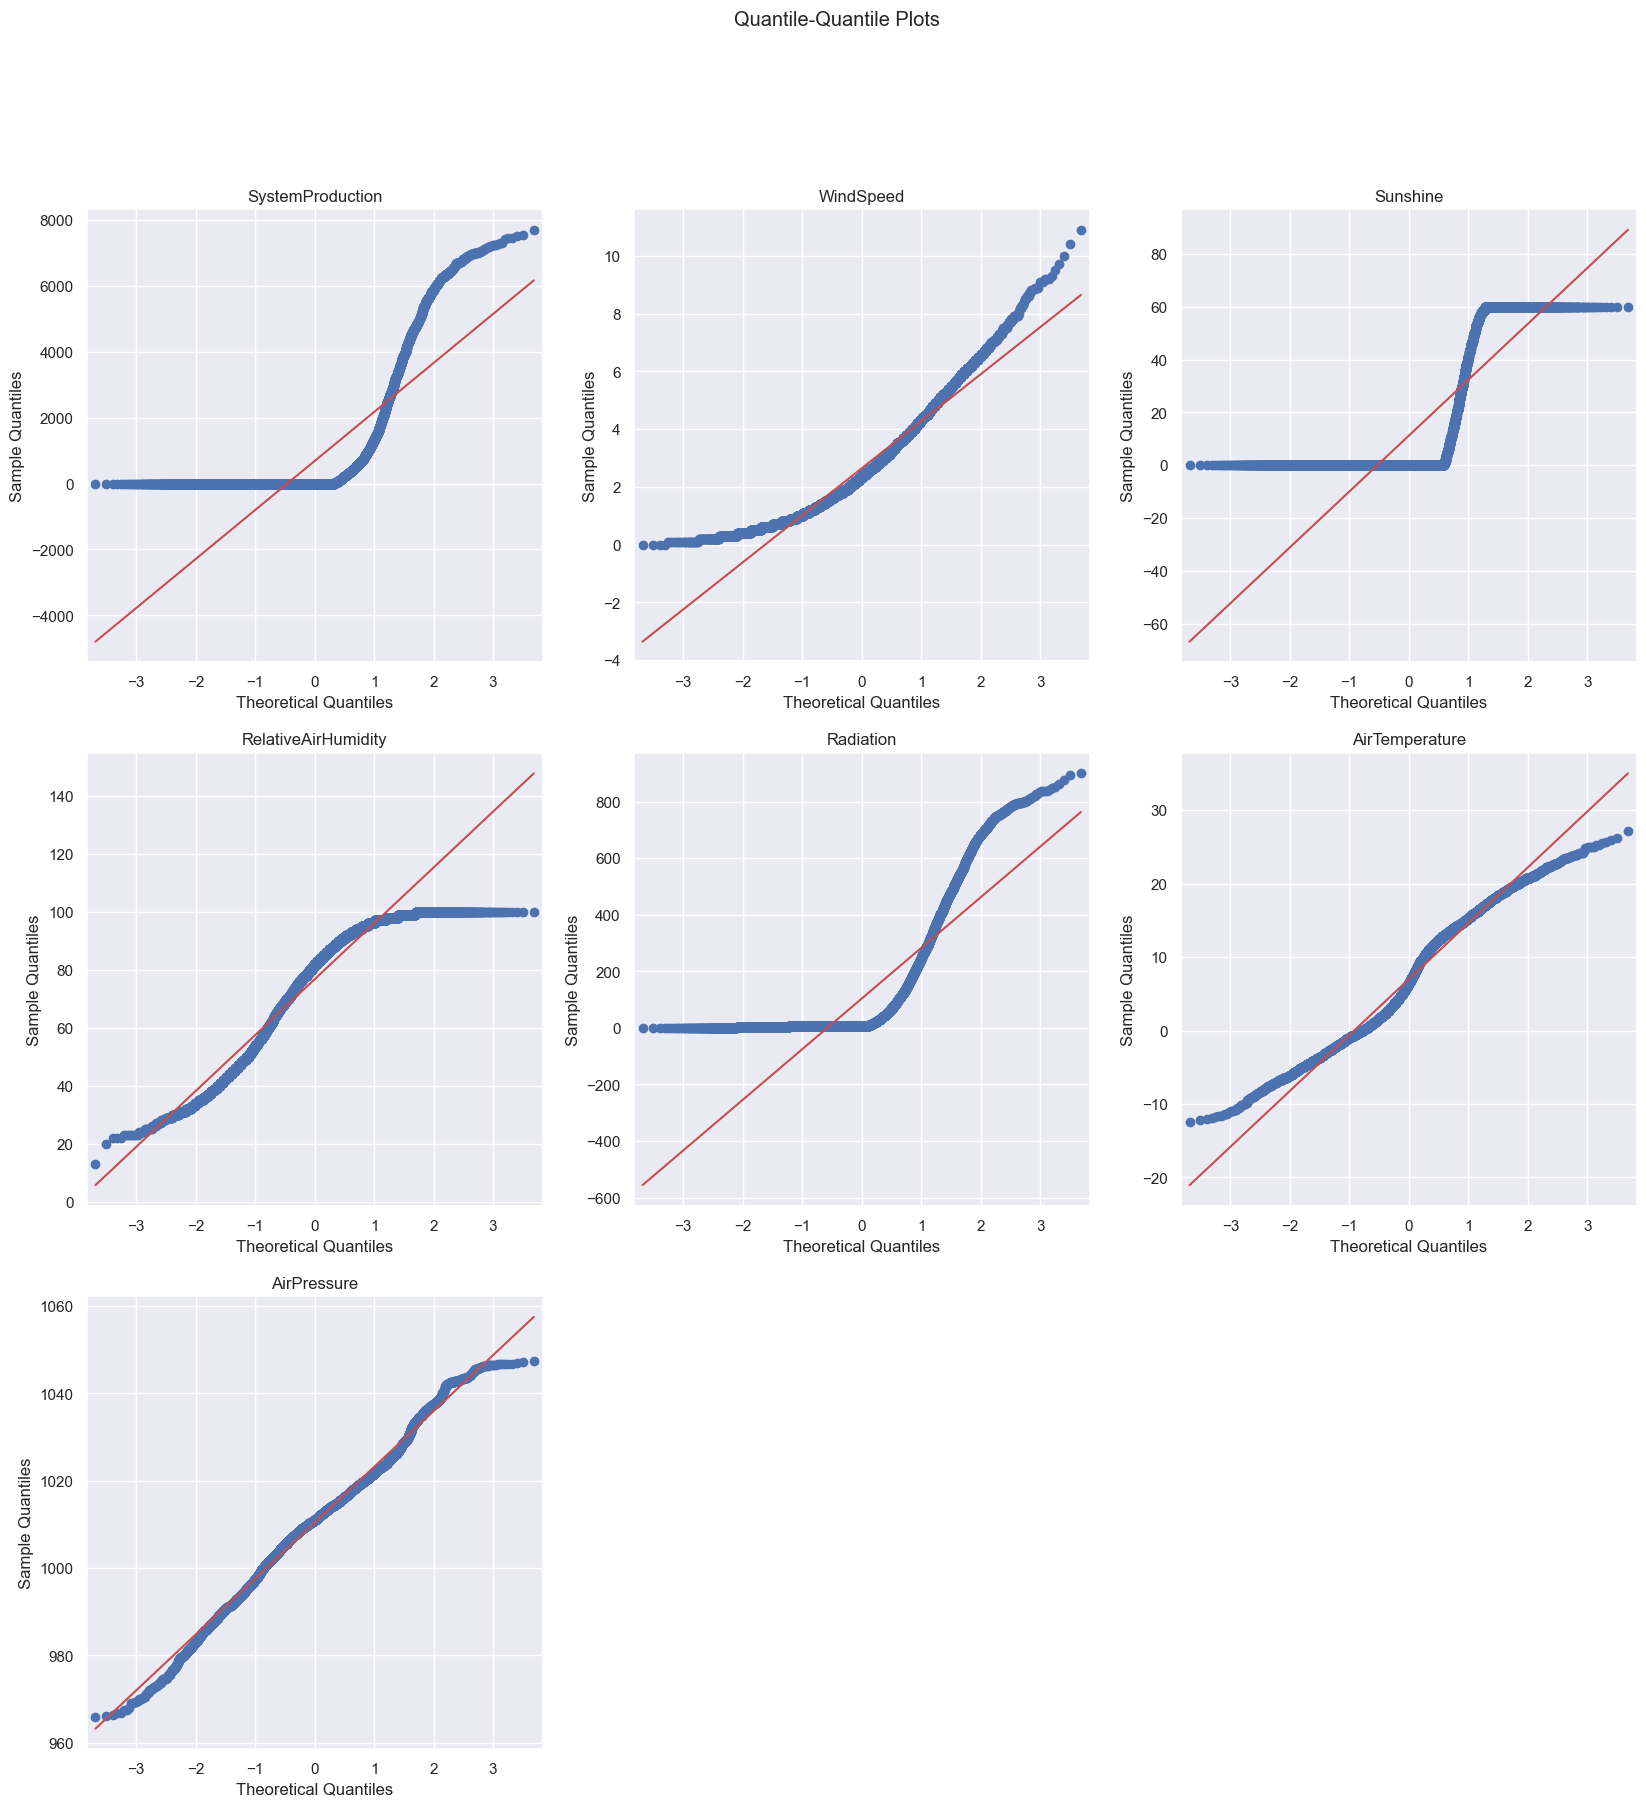

In [68]:
# QQ Plots:
# Defining subplots:
fig, axe = plt.subplots(3, 3, sharey=False, figsize=(20, 20))
fig.suptitle("Quantile-Quantile Plots")
# Plotting SystemProduction data:
qqplot(df["SystemProduction"], ax=axe[0, 0], line="s");
axe[0, 0].set_title("SystemProduction")
# Plotting WindSpeed data:
qqplot(df["WindSpeed"], ax=axe[0, 1], line="s")
axe[0, 1].set_title("WindSpeed")
# Plotting Sunshine data:
qqplot(df["Sunshine"], ax=axe[0, 2], line="s")
axe[0, 2].set_title("Sunshine")
# Ploting RelativeAirHumidity:
qqplot(df["RelativeAirHumidity"], ax=axe[1, 0], line="s")
axe[1, 0].set_title("RelativeAirHumidity")
# Radiation:
qqplot(df["Radiation"], ax=axe[1, 1], line="s")
axe[1, 1].set_title("Radiation")
# AirTemperature:
qqplot(df["AirTemperature"], ax=axe[1, 2], line="s")
axe[1, 2].set_title("AirTemperature")
# AirPressure
qqplot(df["AirPressure"], ax=axe[2, 0], line="s")
axe[2, 0].set_title("AirPressure");
axe[2, 1].set_visible(False)
axe[2, 2].set_visible(False)

As we can see from the qqplot and the Histogram above, it seems tha AirPressure follows a normal distribution. Let's quantify this assumption using statistical tests for normality.

* H0: Data was drew from a normal distribution.
* H1: Data was not drew from a normal distribution.
  
OBS: Using level of significance of 5% (alpha).

OBS2: Shapiro wilk p value is an approximate value due to the size of the sample being more than 5000.

In [69]:
# Function that Calculates Shapiro-Wilk, Lilliefors and D'Agostino_K2 tests:
def normality_tests(df: any):
    tests_names = ["Shapiro-Wilk", "Lilliefors", "D'Agostino_K2"]
    extern_index = np.array(sorted(tests_names*2))
    intern_index = np.array(["statistic", "p-value"]*len(tests_names))
    
    mult_index = [
        extern_index,
        intern_index
    ]
    
    results = pd.DataFrame(index=mult_index, columns=df.columns)
    
    for c in df.columns:
        # First D'Agostino's K-squared test:
        k2, k2_p = normaltest(df[c])
        # Secondly we will use the Lilliefors test:
        lilliefors_result = lilliefors(df[c])
        ksstat, lilliefours_p = lilliefors_result
        # We will check the shapiro-Wilk test:
        shapiro_result = shapiro(df[c])
        shapiro_statistic, shapiro_p = shapiro_result.statistic, shapiro_result.pvalue
        results[c] = [k2, k2_p, ksstat, lilliefours_p, shapiro_statistic, shapiro_p]
    return results

In [70]:
# Function that calculates kurtosis and skewness of a dataset:
def kurtosis_skewness(dataset: any):
    index = ["Kurtosis", "Skewness"]
    results = pd.DataFrame(index=index, columns=dataset.columns)
    
    for c in dataset.columns:
        kurt = kurtosis(dataset[c])
        skewness = skew(dataset[c])
        results[c] = [kurt, skewness]
        
    return results

In [71]:
# Normality test results:
normality_tests(df)

C:\python 3.12\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8760.
  res = hypotest_fun_out(*samples, **kwds)


WindSpeed      Sunshine   AirPressure  \
D'Agostino_K2 statistic   9.806526e+02  2.095571e+03  6.722747e+01   
              p-value    1.132408e-213  0.000000e+00  2.521971e-15   
Lilliefors    statistic   8.657091e-02  4.224024e-01  4.527111e-02   
              p-value     1.000000e-03  1.000000e-03  1.000000e-03   
Shapiro-Wilk  statistic   9.421618e-01  5.596418e-01  9.922033e-01   
              p-value     7.391445e-50  3.679605e-91  1.630528e-21   

                            Radiation  AirTemperature  RelativeAirHumidity  \
D'Agostino_K2 statistic  3.550780e+03    2.245394e+03         7.997811e+02   
              p-value    0.000000e+00    0.000000e+00        2.136654e-174   
Lilliefors    statistic  2.813741e-01    8.151560e-02         1.136078e-01   
              p-value    1.000000e-03    1.000000e-03         1.000000e-03   
Shapiro-Wilk  statistic  6.244945e-01    9.712126e-01         9.158369e-01   
              p-value    1.846923e-87    1.368264e-38         1.556735e-56   

                         SystemProduction  
D'Agostino_K2 statistic      4.487421e+03  
              p-value        0.000000e+00  
Lilliefors    statistic      3.226334e-01  
              p-value        1.000000e-03  
Shapiro-Wilk  statistic      5.321172e-01  
              p-value        1.370636e-92

In [72]:
# Kurtosis and Skewness:
kurtosis_skewness(df)

,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
Kurtosis,0.645685,0.794225,0.413192,3.834403,-1.020777,-0.506118,5.930889
Skewness,0.904462,1.593429,-0.126781,2.126933,0.078606,-0.727069,2.568234


Distribution can be considered normal when:

* Kurtosis between (-1, +1).
* Skewness between (-1, +1).
* Histogram and QQ Plot.

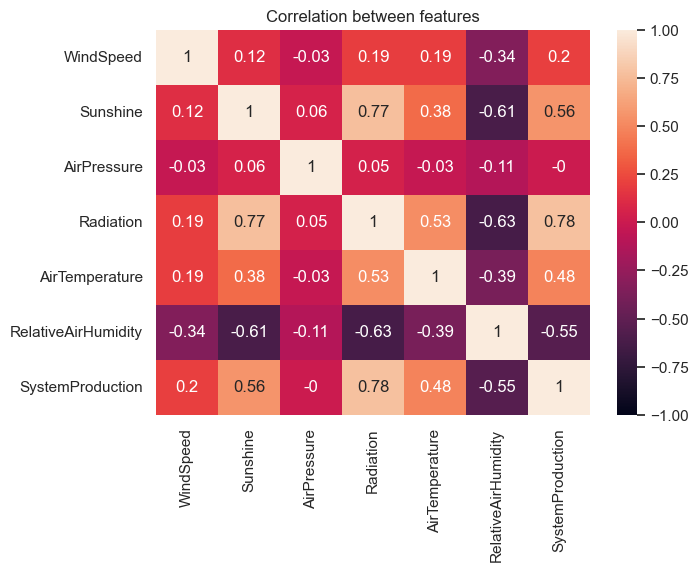

In [73]:
# correlation between features
sns.set()
_, ax = plt.subplots(figsize=(7, 5))

# plot the heatmap of correlations
fig = sns.heatmap(df.corr().round(2), annot=True, vmin=-1, vmax=1, ax=ax);

# set the title
fig.set_title("Correlation between features");

Conclusions

* Most of the data in SystemProduction is 0 as we expected since median is zero and the variable can't be negative.
* Outliers exist in SystemProduction, AirPressure, RelativeHumidity, Radiation, WindSpeed and Sunshine.
* All statistical tests have shown that the AirPressure not follows a normal distribution. However, all these tests are very sensitive when the sample size is large. So we can't rely on them.
* Histogram, QQ Plot, Kurtosis and Skewness tell us that AirPressue follows a normal distribution. Therefore, we will assume that AirPressure is normally distributed.
* Radiation has the highest positive correlation coefficient associated with the SystemProdution (0.79). It is also hightly correlated with Sushine column.
* RelativeAirHumidity has the lowest correlation coefficient associated with the Target. (-0.55)

## Preprocessing

In [74]:
# Separating variables (features and target)
X = df.drop(columns="SystemProduction")
y = df["SystemProduction"]

In [75]:
# Divinding dataset in train and test:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [76]:
# Class that put together many feature selection techniques:
class feature_selector:
    seed = 42
    def __init__(self, X, y) -> None:
        self.X_train = X
        self.y_train = y
    def randomforestR_imp(self):
        model = RandomForestRegressor(random_state=feature_selector.seed)
        model.fit(self.X_train, self.y_train)
        series = pd.Series(index=self.X_train.columns, data=model.feature_importances_)
        # Plotting RandomForest Regression Importance:
        plt.title("RandomForest Importance")
        plt.xlabel("Importance")
        sns.barplot(x=series.values, y=series.index)
        
    def xgbR_imp(self):
        model = XGBRegressor(random_state=feature_selector.seed)
        model.fit(self.X_train, self.y_train)
        series = pd.Series(index=self.X_train.columns, data=model.feature_importances_)
        # Plotting XGboost Regression Feature Importance:
        plt.title("XGBoost Feature Importance")
        plt.xlabel("Importance")
        sns.barplot(y=series.index, x=series.values)
                           
    # Univariate feature selection:
    def univariate(self, statistic, n="all"):
        selector = SelectKBest(score_func=statistic, k=n)
        selector.fit(self.X_train, self.y_train)
        series = pd.Series(index=self.X_train.columns, data=selector.scores_).sort_values(ascending=False)
        plt.title("F-Regression Filtering")
        plt.xlabel("F-score")
        sns.barplot(y=series.index, x=series.values)
        return selector
                           
    # Wrapper method for feature selection:
    def refcv(self):
        models = {
            "Lasso": Lasso(random_state=feature_selector.seed),
            "Ridge": Ridge(random_state=feature_selector.seed),
            "RandomForestR": RandomForestRegressor(random_state=feature_selector.seed),
            "ExtraTreeR": ExtraTreesRegressor(random_state=feature_selector.seed),
            "XGB": XGBRegressor(random_state=feature_selector.seed)
        }
                           
        splits = 10
        cross = KFold(n_splits=splits, random_state=feature_selector.seed, shuffle=True)
        ind = [f"Columns {i}" for i in range(1, len(self.X_train.columns) + 1)]
        df = pd.DataFrame(index=ind)
                           
        minimo = np.inf
        name = ""
        for key, model in models.items():
            rfecv = RFECV(estimator=model, step=1, cv=cross, min_features_to_select=1, scoring='neg_mean_squared_error')
            rfecv.fit(self.X_train, self.y_train)
            root_mean = np.sqrt(-rfecv.cv_results_["mean_test_score"])
            df[key] = root_mean
            best_value = root_mean[np.argmin(root_mean)]
                          
            if minimo > best_value:
                minimo = best_value
                best_features = rfecv.support_
                name = key
                          
        df_features = pd.DataFrame(columns=self.X_train.columns, data=best_features.reshape(1, -1))
        return df, df_features

In [77]:
# Feature selector object:
feature = feature_selector(X_train, y_train)

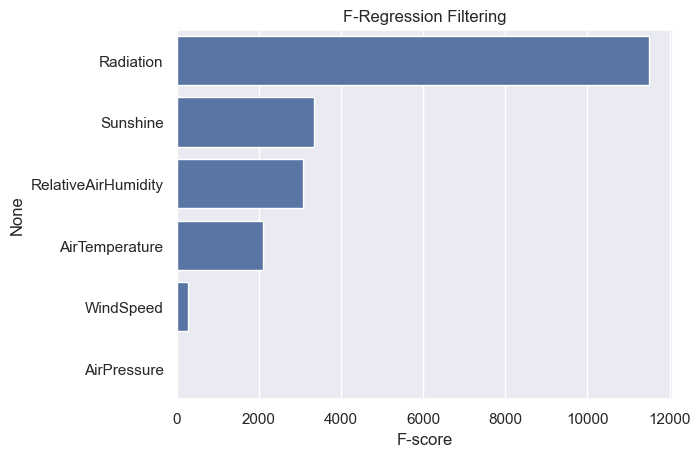

In [78]:
# Filtering feature selection using f_regression test:
selector_filtering = feature.univariate(statistic=f_regression)

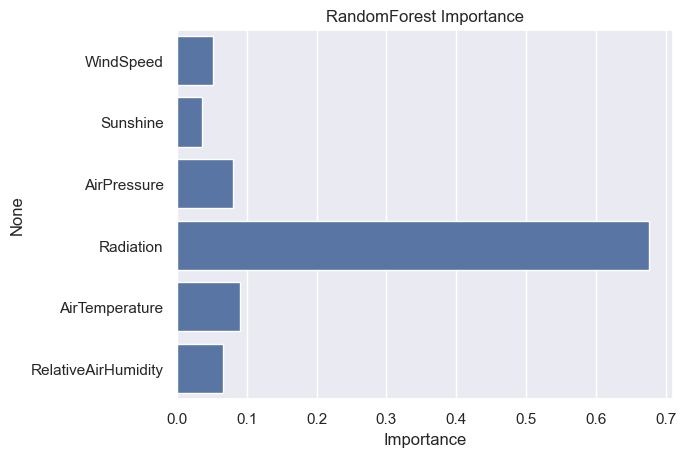

In [79]:
# Plotting Best features accordingly to the Random Forest Algorithm:
feature.randomforestR_imp()

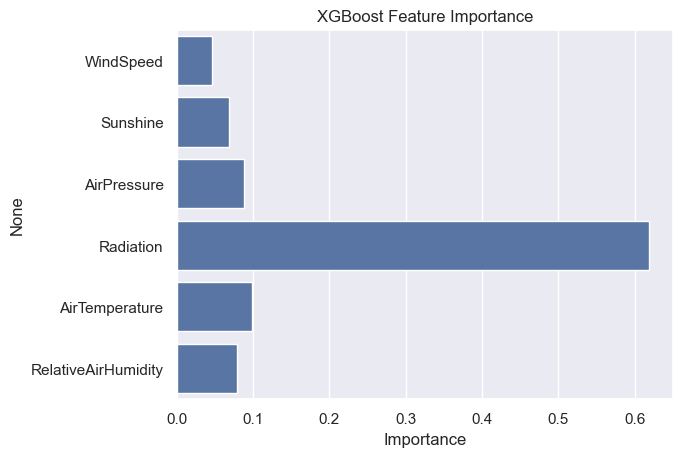

In [80]:
# Plotting the best features accordingly the XGBoost Algorithm:
feature.xgbR_imp()

In [81]:
# Mean test score for all of the Algorithms and for each number of columns:
df_results, df_features = feature.refcv()

In [82]:
# Recursive Feature Elimination results:
df_results

,Lasso,Ridge,RandomForestR,ExtraTreeR,XGB
Columns 1,1467.860960,1477.986141,1133.232244,1208.128417,930.746284
Columns 2,1301.266660,1312.583376,973.530920,1006.214272,1010.475777
Columns 3,1155.614811,1158.127170,849.208397,934.755204,958.257333
Columns 4,1124.590002,1124.589720,819.925069,863.721218,870.654008
Columns 5,907.671105,907.670979,795.234280,790.893194,823.370401
Columns 6,905.333008,905.332963,771.264380,763.449090,788.643649


In [83]:
# Features selected using the best Algorithm (ExtraTreeRegression):

df_features

,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity
0,True,True,True,True,True,True


Transformations

MinMax Scaler

Definition: MinMax Scaler is also called as Normalization, which is a technique that rescale all the values, usually, within a range of 0 and 1.

In [84]:
# MinMax Scaler Transformation:
min_max = MinMaxScaler()
X_train_min_max = min_max.fit_transform(X_train)
X_test_min_max = min_max.transform(X_test)

Standard Scaler

Definition:

The Standard Scaler is a technique that rescales the distribution of a variable so that the mean of the observed sample is 0 and the standard deviation is:-
* It is particularly useful for algorithms that rely on distance measures, such as K-means and K-nearest neighbors (KNN). Additionally, it is a recommended choice for algorithms based on neural networks.
  
OBS: Standard Scaler can perform slightly worst than the other transformations because it assumes that the data is normally distributed. However you can still standarduze your data.

In [85]:
# Standard Scaler Transformation:
std = StandardScaler()
X_train_std = std.fit_transform(X_train)
X_test_std = std.transform(X_test)

In [86]:
# Robust Scaler Transformation:
rob = RobustScaler()
X_train_rb = rob.fit_transform(X_train)
X_test_rb = rob.fit_transform(X_test)

In [87]:
# Function used to evaluate the best algorithms:
def best_model(X_train, y_train):
    
    seed = 42
    cv = 5
    score = ['neg_root_mean_squared_error', 'r2']
    result_rmse = {}
    result_r2 = {}
    
    dicionario = {
                "Lasso":Lasso(random_state=seed),
                "Ridge":Ridge(random_state=seed),
                "SVR":SVR(),
                "RandomForestR":RandomForestRegressor(random_state=seed),
                "ExtraTreeR":ExtraTreesRegressor(random_state=seed),
                "XGB":XGBRegressor(random_state=seed),
                "MLP":MLPRegressor(random_state=seed, max_iter=2000)
                }
    
    for name, model in dicionario.items():
        
        k_fold = KFold(n_splits=cv, random_state=seed, shuffle=True)
        result = cross_validate(model, X_train, y_train, cv=k_fold, scoring=score)
        result_rmse[name] = -result['test_neg_root_mean_squared_error']
        result_r2[name] = result['test_r2']
        result_pd_rmse = pd.DataFrame(data=result_rmse)
        result_pd_r2 = pd.DataFrame(data=result_r2)
        
    return result_pd_rmse, result_pd_r2

#### Algorithms using Standard Scaler

In [88]:
# Best model:
result_rms, result_r2 = best_model(X_train_std, y_train)

In [89]:
# Root mean squared error results:
result_rms.describe()

,Lasso,Ridge,SVR,RandomForestR,ExtraTreeR,XGB,MLP
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,905.083522,905.073494,1531.996500,774.790430,776.900743,791.167159,863.177387
std,15.679562,15.695652,77.428643,44.129379,35.854308,43.152908,23.028835
min,885.767144,885.753931,1409.256885,710.121367,715.939529,716.205357,830.280926
25%,898.301411,898.324096,1510.351374,762.099017,773.782864,795.325133,857.470613
50%,899.490228,899.390137,1558.412439,779.106247,794.675784,807.987896,864.355971
75%,917.004775,917.063229,1571.092043,791.818381,796.301087,812.154163,869.543191
max,924.854054,924.836078,1610.869760,830.807136,803.804449,824.163247,894.236236


In [90]:
# R2 results:
result_r2.describe()

,Lasso,Ridge,SVR,RandomForestR,ExtraTreeR,XGB,MLP
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.636987,0.636996,-0.035944,0.734519,0.733347,0.723579,0.670199
std,0.026973,0.026962,0.015601,0.021437,0.010975,0.013715,0.019402
min,0.597617,0.597629,-0.053081,0.705518,0.715847,0.707445,0.646450
25%,0.635074,0.635088,-0.049706,0.719037,0.730575,0.710209,0.658836
50%,0.637431,0.637512,-0.036143,0.741378,0.737123,0.730136,0.670514
75%,0.641245,0.641199,-0.022242,0.752213,0.738635,0.733177,0.677420
max,0.673569,0.673553,-0.018546,0.754450,0.744558,0.736928,0.697774


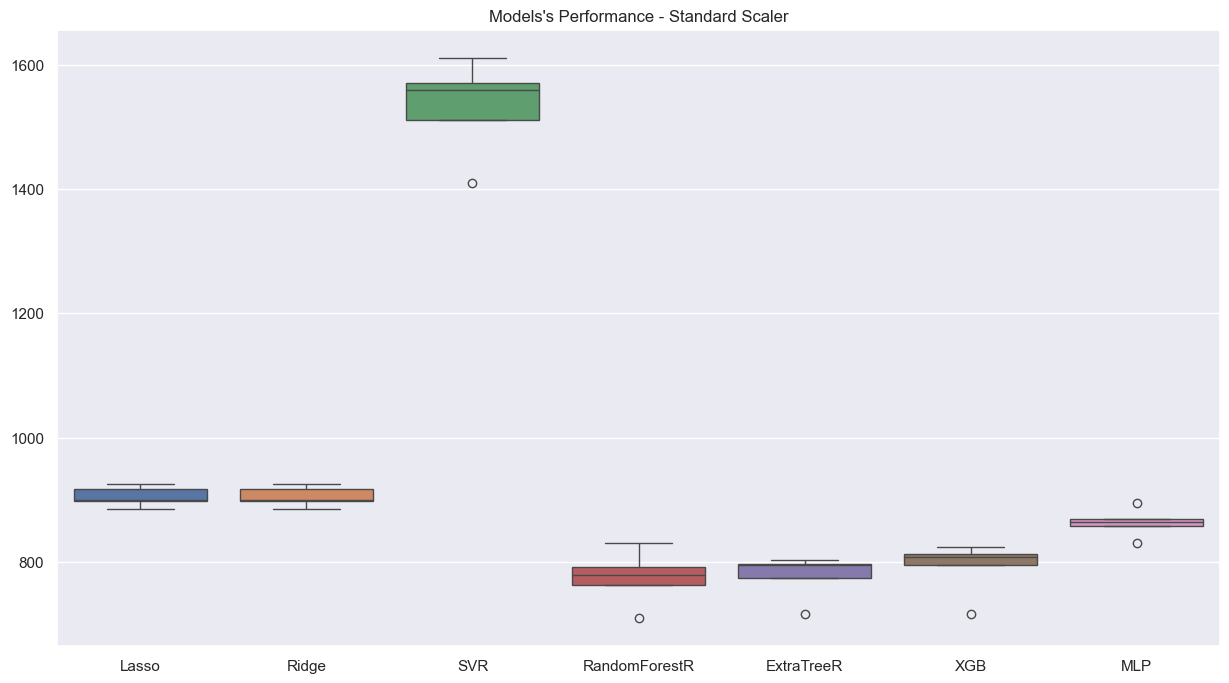

In [91]:
# PLotting model's performance:
plt.figure(figsize=(15, 8))
plt.title("Models's Performance - Standard Scaler")
sns.boxplot(result_rms);

Algorithms using Robust Scaler

In [92]:
# Best model:
result_rms, result_r2 = best_model(X_train_rb, y_train)
# Root mean squared error results:
result_rms.describe()
# R2 results:
result_r2.describe()

,Lasso,Ridge,SVR,RandomForestR,ExtraTreeR,XGB,MLP
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.636989,0.636996,0.032927,0.734268,0.733322,0.723579,0.659328
std,0.026982,0.026966,0.018509,0.021402,0.011010,0.013715,0.029870
min,0.597599,0.597621,0.015258,0.706040,0.715847,0.707445,0.612763
25%,0.635069,0.635087,0.016215,0.717583,0.730575,0.710209,0.657499
50%,0.637487,0.637521,0.031643,0.741775,0.737123,0.730136,0.663338
75%,0.641213,0.641194,0.042359,0.752330,0.738165,0.733177,0.667445
max,0.673579,0.673558,0.059160,0.753614,0.744901,0.736928,0.695596


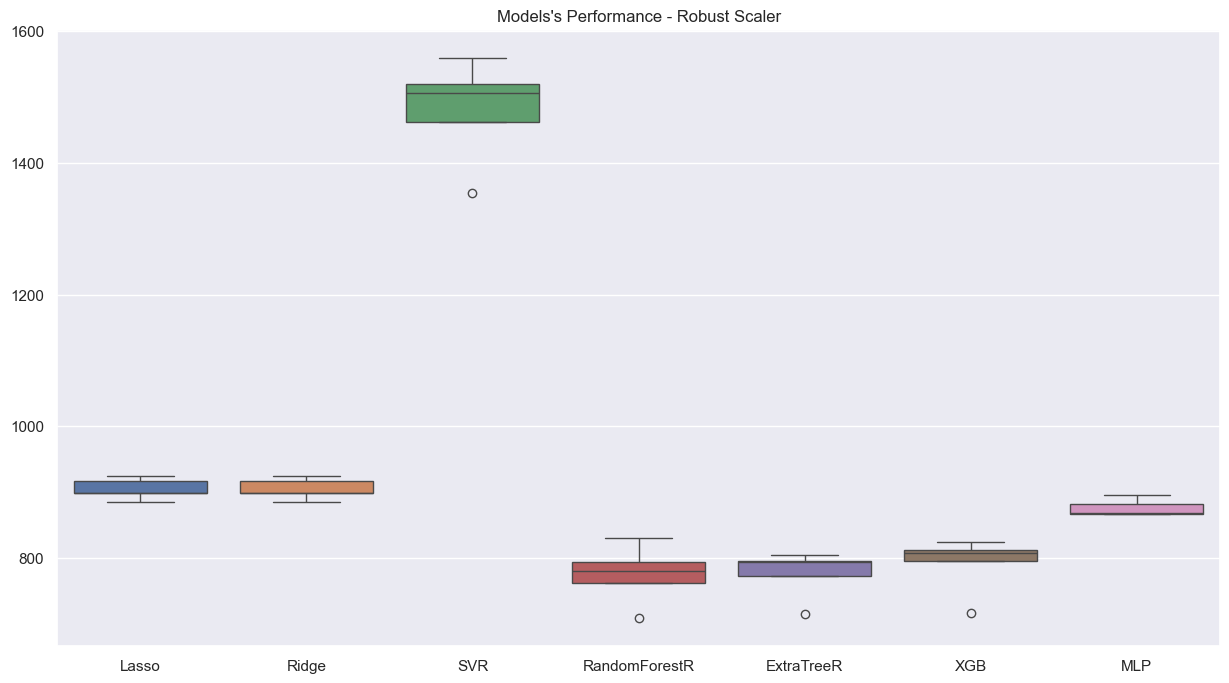

In [93]:
# PLotting model's performance:
plt.figure(figsize=(15, 8))
plt.title("Models's Performance - Robust Scaler")
sns.boxplot(result_rms);

#### Conclusions

* ExtraTres was the best Algorithm for all of the transformation algorithms.
* The Best Trasformation algorithm was Robust Scaler.
* 
##### RMSE:

Average: 775.018174
Standard Deviation: 37.423964
R2

##### Average: 0.734621
Standard Deviation: 0.012831
Fine Tuning

#### Conclusions

ExtraTres was the best Algorithm for all of the transformation algorithms.
The Best Trasformation algorithm was Robust Scaler.
RMSE:

Average: 775.018174
Standard Deviation: 37.423964
R2

Average: 0.734621
Standard Deviation: 0.012831
Fine Tuning

In [94]:
# Function for fine tuning an arbitrary model:
def tuning(X_train, y_train, modelo, params):
    cv = 5
    score = "neg_root_mean_squared_error"
    grid = GridSearchCV(modelo, cv=cv, param_grid=params,
                        scoring=score,n_jobs=-1,
                        return_train_score=True,
                       )
    
    grid.fit(X_train, y_train)
    
    best_index = grid.best_index_
    result = grid.cv_results_
    
    train_score = -result['mean_train_score'][best_index]
    left_out = -result['mean_test_score'][best_index]
    
    print(f"Train score: {train_score}")
    print(f"Left out data score: {left_out}")
    
    return grid.best_estimator_

In [95]:
def save_model(model):
    try:
        joblib.dump(model, "model/extra_tree_model.joblib")
    except:
        os.makedirs("model")
        path = "model/extra_tree_model.joblib"
        joblib.dump(model, path)

In [96]:
# Hypeparameters grid:
params = {"n_estimators":[100, 110, 120],
    "max_depth":[4, 5, 6, 7],
    "max_features":[0.5, 0.6, 0.7],
    "min_samples_split":[3, 5, 6, 7, 10]}

In [97]:
# Fine Tuning an ExtraTreeRegressor:
extra_tree = ExtraTreesRegressor(random_state=42)
best_estimator = tuning(X_train_rb, y_train, extra_tree, params)

C:\python 3.12\Lib\site-packages\numpy\ma\core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Train score: 766.9279190926829
Left out data score: 836.8886036554438


In [98]:
# Saving the best model:
save_model(best_estimator)

## Predictions

In [99]:
# Training the best model using the whole training set:
best_model = clone(best_estimator)
best_model.fit(X_train_rb, y_train)

ExtraTreesRegressor(max_depth=7, max_features=0.7, min_samples_split=5,
                    n_estimators=110, random_state=42)

In [100]:
# Computing Metrics for the training set:
y_pred = best_model.predict(X_train_rb)
rms_train = np.sqrt(mean_squared_error(y_pred, y_train))
r2_train = r2_score(y_pred, y_train)
print("Train set:")
print(f"RMSE: {rms_train}")
print(f"R2: {r2_train}")

Train set:
RMSE: 778.6605543441677
R2: 0.5648065925561975


In [101]:
# Computing Metrics for the test set:
y_pred = best_model.predict(X_test_rb)
rmse_test = np.sqrt(mean_squared_error(y_pred, y_test))
r2_test = r2_score(y_pred, y_test)
print("Test set:")
print(f"RMSE: {rmse_test}")
print(f"R2: {r2_test}")

Test set:
RMSE: 812.4921213255561
R2: 0.5428239875311067


## Conclusions
* RMSE improved from 835.595 to 819.731.
* R2 score is approximately 0.5349.
* Model does not seem to suffer from Overfitting.